In [16]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download(handle="akshayramakrishnan28/fracture-classification-dataset", output_dir="data")

print("Path to dataset files:", path)

Path to dataset files: data


In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
from PIL import Image
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv(path + "/FracAtlas/dataset.csv")

images_data = []
labels_data = []
image_ids_valid = []
base_path = path + "/FracAtlas/images"

corrupted_count = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):
    image_id = row['image_id']
    is_fractured = row['fractured']

    folder = 'Fractured' if is_fractured == 1 else 'Non_fractured'
    image_path = os.path.join(base_path, folder, image_id)

    try:
        if os.path.exists(image_path):
            img = Image.open(image_path).convert('RGB')
            img = img.resize((224, 224))
            img_array = np.array(img)

            images_data.append(img_array)
            labels_data.append(is_fractured)
            image_ids_valid.append(image_id)
        else:
            print(f"Image not found: {image_id}")
    except (OSError, IOError) as e:
        corrupted_count += 1

X = np.array(images_data, dtype=np.float32) / 255.0
y = np.array(labels_data)

100%|██████████| 4083/4083 [00:25<00:00, 161.82it/s]


In [28]:
x_train_T, x_test, y_train_T, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

N_train_T = np.shape(x_train_T)[0]
N_train = round(0.8*N_train_T) # 80% for train and 20% for validation
x_train,y_train = x_train_T[0:N_train],y_train_T[0:N_train]
x_val,y_val = x_train_T[N_train:],y_train_T[N_train:]

print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(2575, 224, 224, 3)
(2575,)
(644, 224, 224, 3)
(644,)


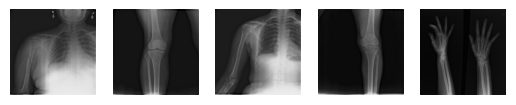

In [29]:
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.axis('off')
plt.show()